Projekat: Klasterovanje kupaca online prodavnice na osnovu ponašanja
Opis: Generisaćemo veštački skup podataka koji opisuje korisnike online prodavnice. Svaki korisnik ima sledeće karakteristike:

Broj poseta sajtu

Broj proizvoda pregledanih po poseti

Prosečno vreme provedeno na sajtu

Ukupan broj stavki dodatih u korpu

Broj kupljenih proizvoda

Ukupna potrošnja

Zemlja korisnika (kategorizovana)

Cilj projekta je da pomoću klasterovanja (npr. KMeans, DBSCAN, GMM) grupišemo korisnike u različite segmente: npr. lojalni kupci, povremeni, posetioci bez kupovine itd.

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs
import random

# Broj korisnika
num_users = 10000

# Generišemo osnovne klastere pomoću make_blobs (samo za vizuelnu distribuciju kasnije)
X, _ = make_blobs(n_samples=num_users, centers=4, n_features=2, random_state=42)
X = np.abs(X)  # Obezbedimo da su sve vrednosti pozitivne

# Pretvaramo u DataFrame
df = pd.DataFrame(X, columns=["site_visits", "products_viewed_per_visit"])

# Dodajemo druge kolone na osnovu logike i malo nasumičnosti
df["avg_time_on_site"] = np.round(np.random.normal(loc=5, scale=2, size=num_users), 2)
df["avg_time_on_site"] = df["avg_time_on_site"].apply(lambda x: max(1, x))  # vreme u minutima

df["items_in_cart"] = np.random.poisson(lam=3, size=num_users)
df["purchases"] = [min(cart, random.choices([0, 1, 2, 3], [0.4, 0.3, 0.2, 0.1])[0]) for cart in df["items_in_cart"]]
df["total_spent"] = df["purchases"] * np.random.uniform(5, 100, size=num_users)

# Zemlja korisnika (kategorijalna)
countries = ['USA', 'Germany', 'France', 'Italy', 'India', 'Brazil']
df["country"] = np.random.choice(countries, size=num_users, p=[0.2, 0.15, 0.15, 0.15, 0.2, 0.15])

# Finalni pregled
print(df.head())

# Čuvanje u CSV fajl ako želiš
df.to_csv("generated_online_store_users.csv", index=False)


   site_visits  products_viewed_per_visit  avg_time_on_site  items_in_cart  \
0     2.968854                   7.934444              2.28              4   
1     8.358301                   9.109786              4.36              4   
2     5.253650                   2.348626              4.35              3   
3     7.715966                   8.746558              6.50              2   
4     6.178372                   6.157039              6.29              3   

   purchases  total_spent country  
0          1    19.033746     USA  
1          0     0.000000  Brazil  
2          0     0.000000  France  
3          1    26.286067  Brazil  
4          2    31.343441   India  


EDA

        site_visits  products_viewed_per_visit  avg_time_on_site  \
count  10000.000000               10000.000000      10000.000000   
mean       5.710386                   6.310936          5.005726   
std        2.576600                   2.803749          1.945748   
min        0.017735                   0.002794          1.000000   
25%        3.554100                   4.384993          3.650000   
50%        5.731024                   7.096170          4.960000   
75%        7.809057                   8.290661          6.320000   
max       12.694703                  12.940524         13.990000   

       items_in_cart     purchases   total_spent  
count   10000.000000  10000.000000  10000.000000  
mean        2.994500      0.865700     45.363529  
std         1.731927      0.906171     58.356654  
min         0.000000      0.000000      0.000000  
25%         2.000000      0.000000      0.000000  
50%         3.000000      1.000000     21.862727  
75%         4.000000      1.00

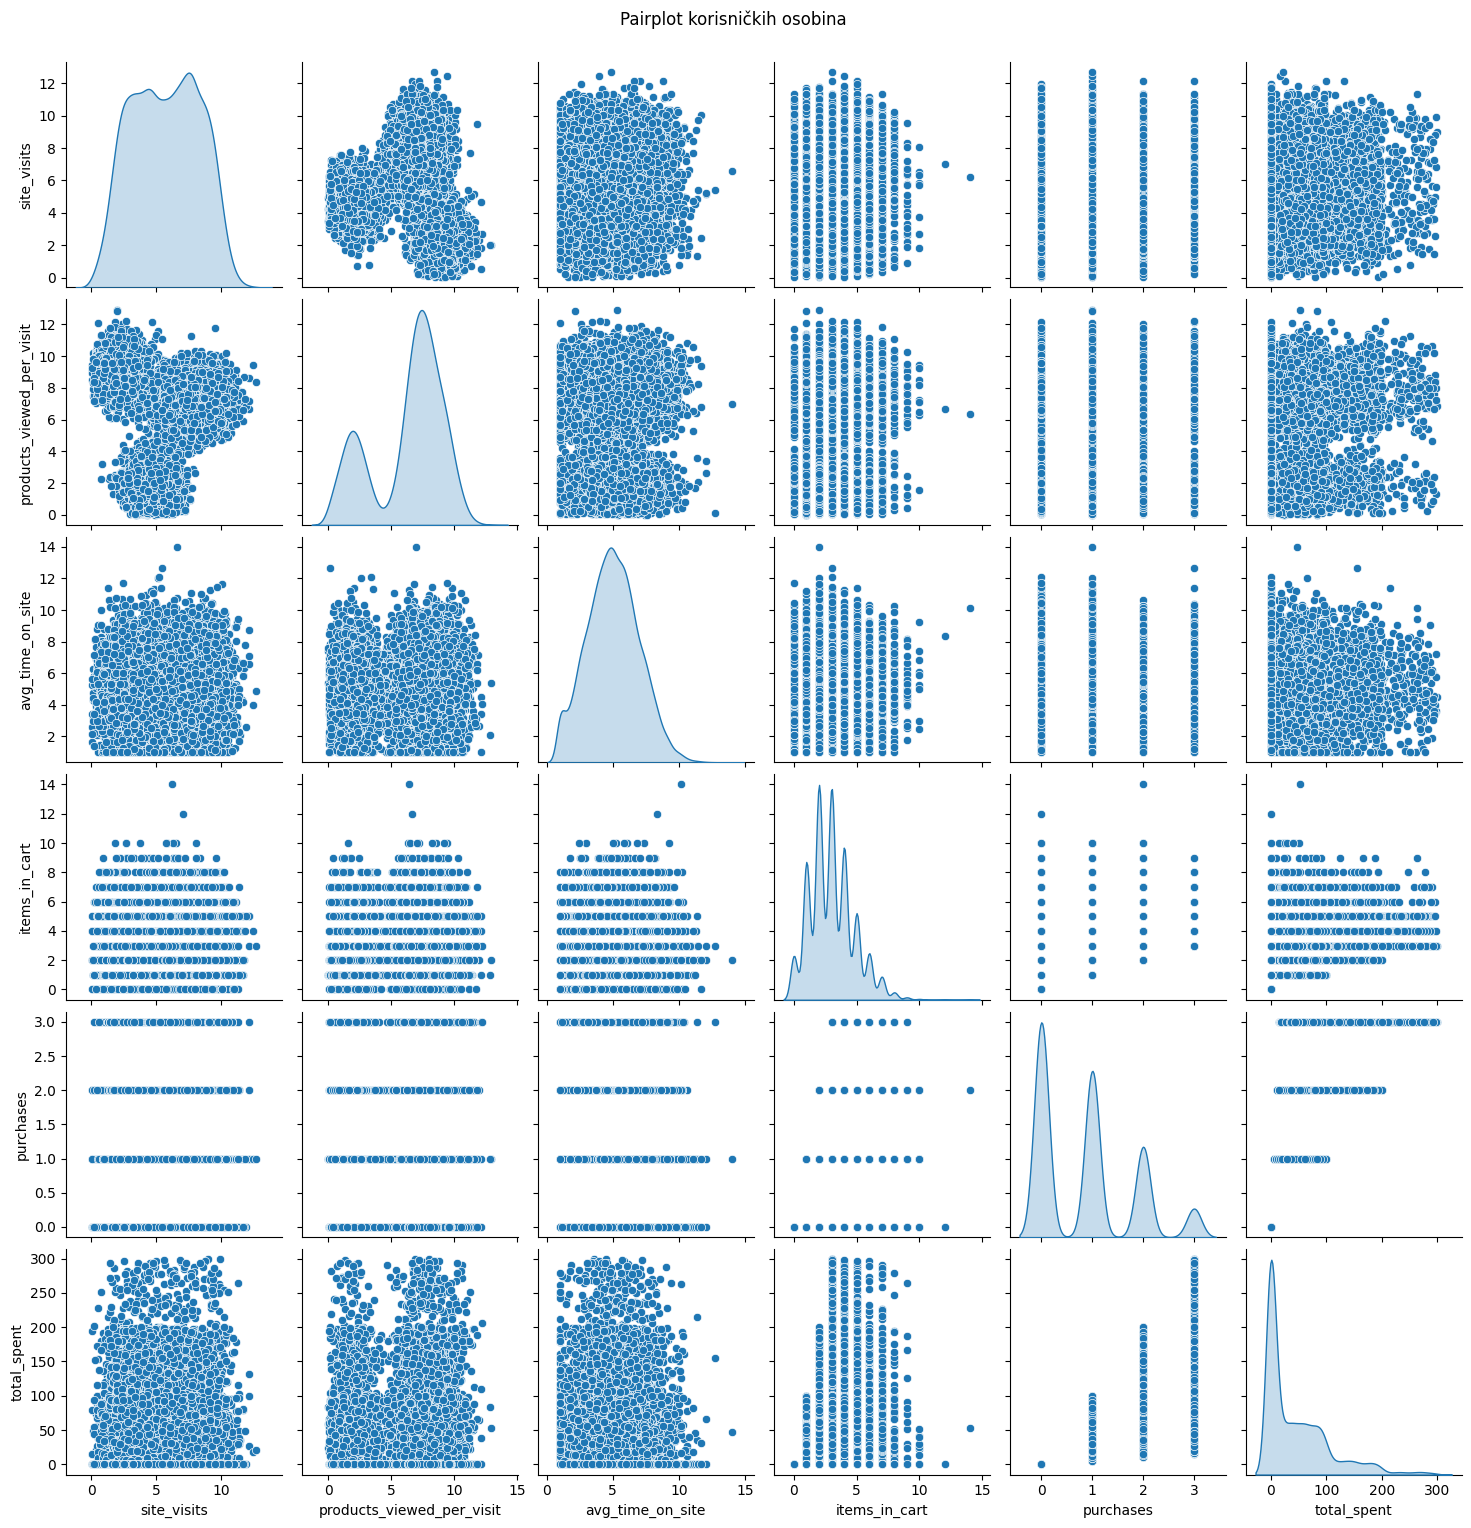

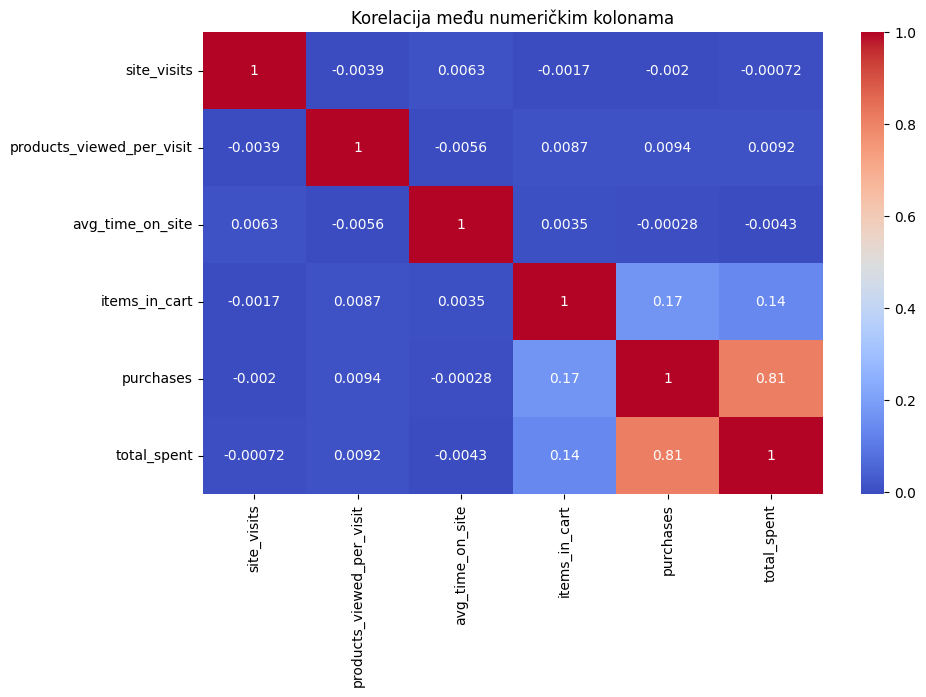

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

# Provera osnovne statistike
print(df.describe())

# Provera broja korisnika po zemlji
print(df["country"].value_counts())

# Vizualizacija - par odnosa
sns.pairplot(df.drop(columns=["country"]), diag_kind="kde")
plt.suptitle("Pairplot korisničkih osobina", y=1.02)
plt.show()

# Korelaciona matrica
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=["country"]).corr(), annot=True, cmap="coolwarm")
plt.title("Korelacija među numeričkim kolonama")
plt.show()


Obrada podataka za klaseterovanje

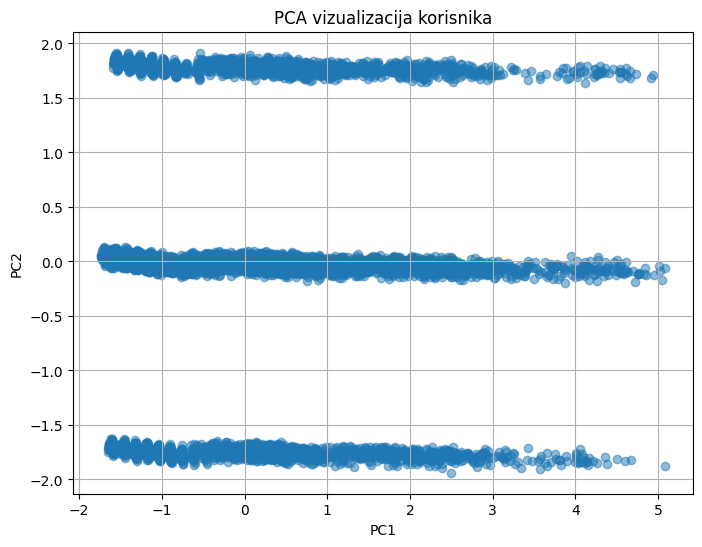

In [3]:
# Kopija originalnog DataFrame-a
df_clean = df.copy()

# One-hot encoding za zemlju
df_encoded = pd.get_dummies(df_clean["country"], prefix="country")
df_clean = pd.concat([df_clean.drop(columns=["country"]), df_encoded], axis=1)

# Skaliranje podataka
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

# PCA za smanjenje dimenzionalnosti (radi lakše vizualizacije i klasterovanja)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Pretvaramo nazad u DataFrame radi vizualizacije
df_pca = pd.DataFrame(pca_data, columns=["PC1", "PC2"])

# Prikaz PCA rezultata
plt.figure(figsize=(8, 6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.5)
plt.title("PCA vizualizacija korisnika")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


Klasterovanje Kmeans

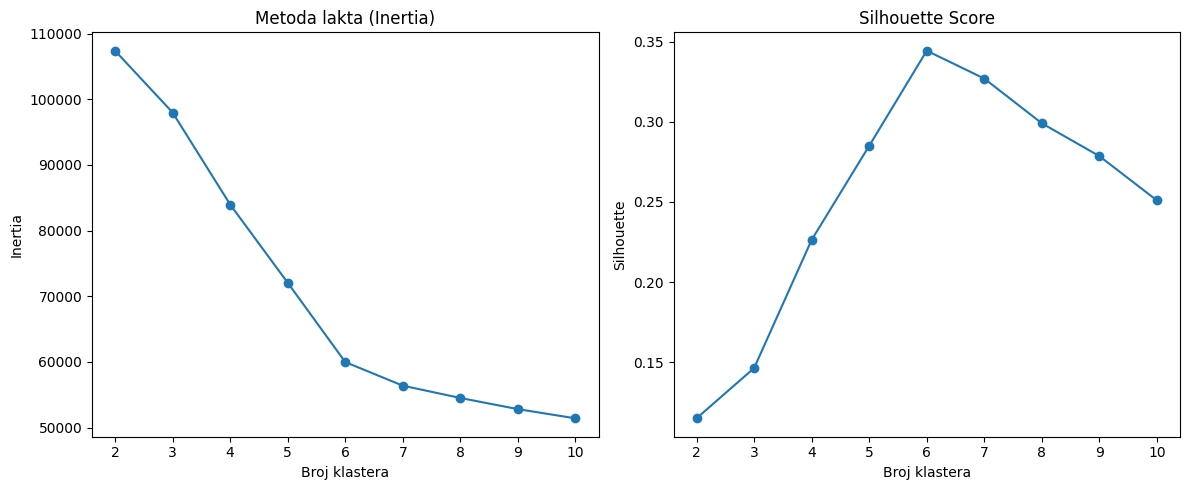

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Odabir broja klastera pomoću metode lakta
inertia = []
silhouette = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(scaled_data, kmeans.labels_))

# Prikaz grafikona
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertia, marker='o')
plt.title("Metoda lakta (Inertia)")
plt.xlabel("Broj klastera")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Broj klastera")
plt.ylabel("Silhouette")

plt.tight_layout()
plt.show()


Testirano kmenans sa najboljim brojem klastera

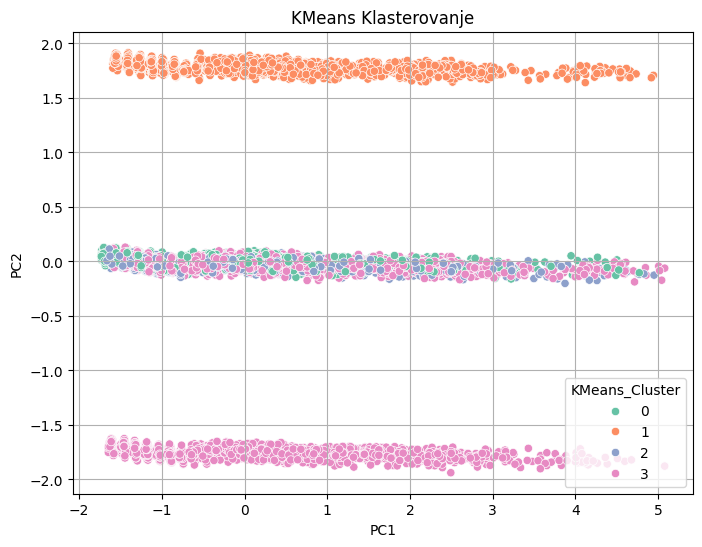

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

# Dodamo klastere u PCA data
df_pca["KMeans_Cluster"] = kmeans_labels

# Vizualizacija
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="KMeans_Cluster", palette="Set2")
plt.title("KMeans Klasterovanje")
plt.grid(True)
plt.show()


DBSCAN

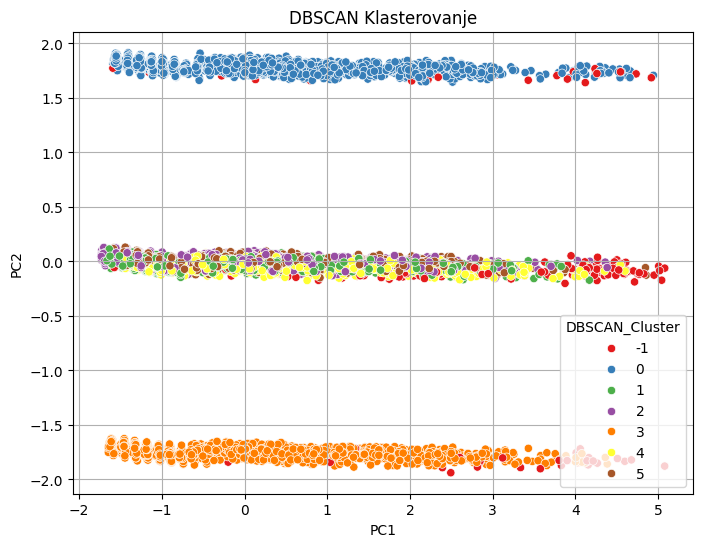

In [6]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(scaled_data)

df_pca["DBSCAN_Cluster"] = dbscan_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="DBSCAN_Cluster", palette="Set1")
plt.title("DBSCAN Klasterovanje")
plt.grid(True)
plt.show()


gaussian mixture model (gmm)

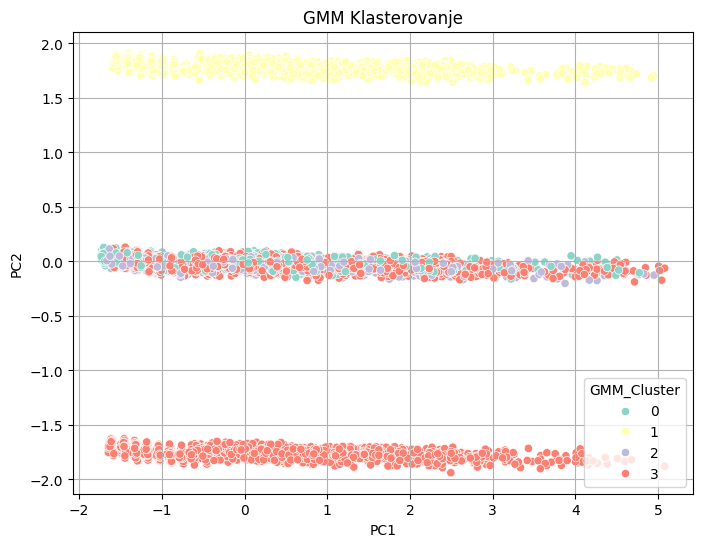

In [7]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(scaled_data)

df_pca["GMM_Cluster"] = gmm_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="GMM_Cluster", palette="Set3")
plt.title("GMM Klasterovanje")
plt.grid(True)
plt.show()


Analiza klastera(KMEANS)

In [8]:
# Kopiramo skalirani dataset sa originalnim vrednostima
df_clustered = df.copy()
df_clustered["Cluster"] = kmeans_labels


-broj korisnika po klasteru

In [9]:
print(df_clustered["Cluster"].value_counts())


Cluster
3    5007
1    2004
2    1506
0    1483
Name: count, dtype: int64


-statisticki pregled po klasterima

In [10]:
cluster_summary = df_clustered.groupby("Cluster").mean(numeric_only=True)
print(cluster_summary)


         site_visits  products_viewed_per_visit  avg_time_on_site  \
Cluster                                                             
0           5.753877                   6.336867          4.984349   
1           5.717698                   6.304063          4.991856   
2           5.673768                   6.317244          5.010558   
3           5.705592                   6.304110          5.016155   

         items_in_cart  purchases  total_spent  
Cluster                                         
0             3.025624   0.833446    42.617343  
1             2.948104   0.890220    46.806686  
2             3.000000   0.851926    45.036804  
3             3.002197   0.869583    45.697571  


vizuelizacija ponasanja po klasterima

<Figure size 1200x600 with 0 Axes>

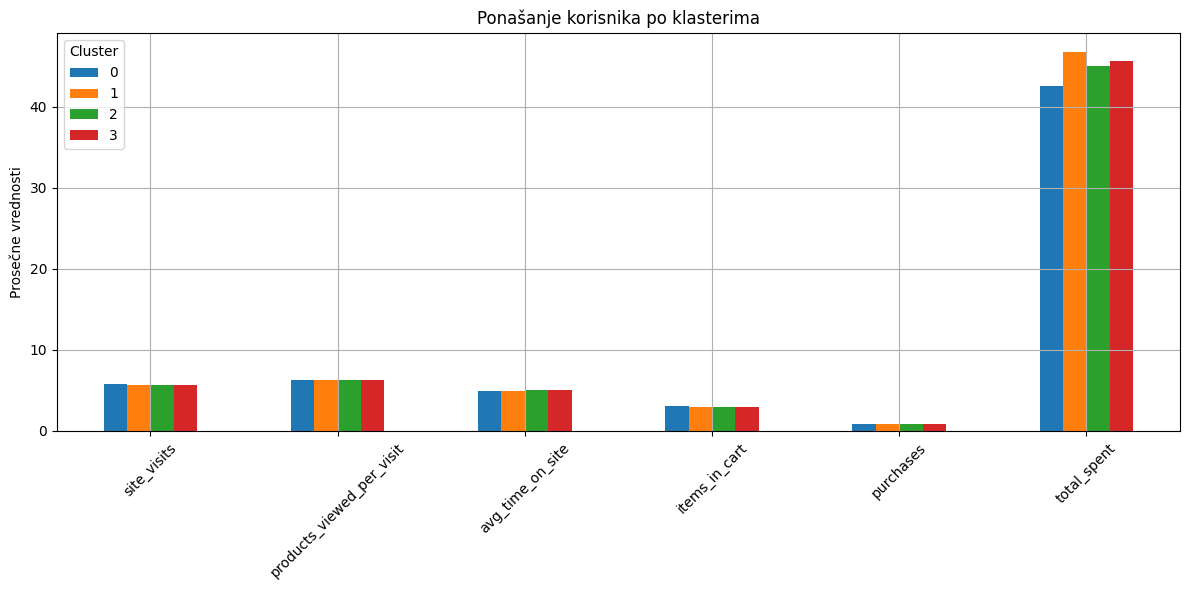

In [11]:
# Bar plot prosečnih vrednosti atributa po klasteru
plt.figure(figsize=(12, 6))
cluster_summary.T.plot(kind="bar", figsize=(12, 6))
plt.title("Ponašanje korisnika po klasterima")
plt.ylabel("Prosečne vrednosti")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


Primer interpretacije klastera:
Na osnovu prosečnih vrednosti iz cluster_summary, možemo formulisati profile. Na primer:

Klaster 0 – “Lojalni kupci”
Visok broj poseta i pregledanih proizvoda

Mnogo stavki u korpi i kupljenih proizvoda

Visoka ukupna potrošnja

Vredno ih zadržati – nuditi popuste i programe lojalnosti

Klaster 1 – “Posetioci bez kupovine”
Često posećuju sajt, ali retko kupuju

Niska potrošnja

Potrebna bolja konverzija – ciljati sa personalizovanim oglasima

Klaster 2 – “Impulsivni kupci”
Nizak broj poseta, ali visoka prosečna potrošnja po kupovini

Fokusirati se na preporuke i “limited time offers”

Klaster 3 – “Prosečni korisnici”
Umeren broj poseta i potrošnje

Možda se mogu konvertovati u lojalne uz podsticaje

Analiza gmm klastera

In [12]:
df_gmm = df.copy()
df_gmm["GMM_Cluster"] = gmm_labels


broj korisnika po gmm klasteru

In [13]:
print(df_gmm["GMM_Cluster"].value_counts())


GMM_Cluster
3    5007
1    2004
2    1506
0    1483
Name: count, dtype: int64


Statisticki pregled po gmm klasterima

In [14]:
gmm_summary = df_gmm.groupby("GMM_Cluster").mean(numeric_only=True)
print(gmm_summary)


             site_visits  products_viewed_per_visit  avg_time_on_site  \
GMM_Cluster                                                             
0               5.753877                   6.336867          4.984349   
1               5.717698                   6.304063          4.991856   
2               5.673768                   6.317244          5.010558   
3               5.705592                   6.304110          5.016155   

             items_in_cart  purchases  total_spent  
GMM_Cluster                                         
0                 3.025624   0.833446    42.617343  
1                 2.948104   0.890220    46.806686  
2                 3.000000   0.851926    45.036804  
3                 3.002197   0.869583    45.697571  


vizuelizacija ponasanja korisnika po gmm klasterima

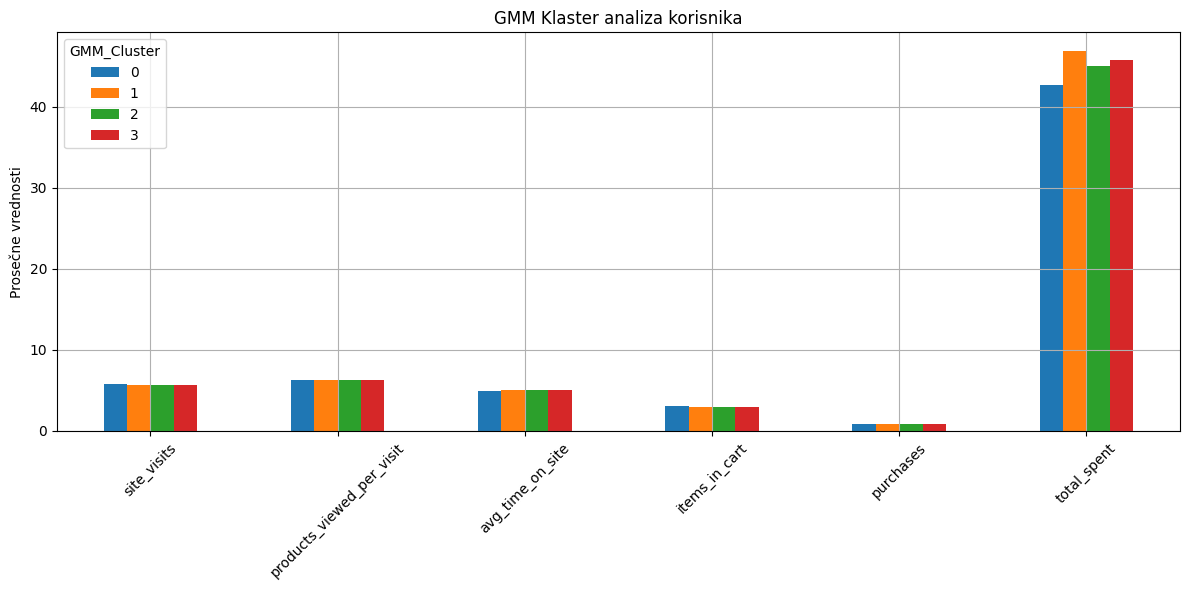

In [15]:
# Bar plot prosečnih vrednosti atributa po GMM klasterima
gmm_summary.T.plot(kind="bar", figsize=(12, 6))
plt.title("GMM Klaster analiza korisnika")
plt.ylabel("Prosečne vrednosti")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


Poredjenje sa kmeans klasterima

In [16]:
comparison = pd.DataFrame({
    "KMeans": kmeans_labels,
    "GMM": gmm_labels
})

# Crosstab (koliko se poklapaju)
ct = pd.crosstab(comparison["KMeans"], comparison["GMM"])
print(ct)


GMM        0     1     2     3
KMeans                        
0       1483     0     0     0
1          0  2004     0     0
2          0     0  1506     0
3          0     0     0  5007


Na osnovu gmm_summary, možemo opisati GMM klastere kao i ranije:

GMM Klaster 0 – recimo da ima nisku potrošnju, nisku aktivnost → pasivni korisnici

GMM Klaster 1 – viša potrošnja i više aktivnosti → lojalni korisnici

GMM Klaster 2 – srednja vrednost svega → prosečni

GMM Klaster 3 – korisnici sa visokim brojem stavki u korpi, ali niskim brojem kupovina → odustaju od kupovine

Vizuelizacija potrosnje po klasterima

<ipython-input-17-7aa9463b8f1e>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clustered, x="Cluster", y="total_spent", palette="Set2")


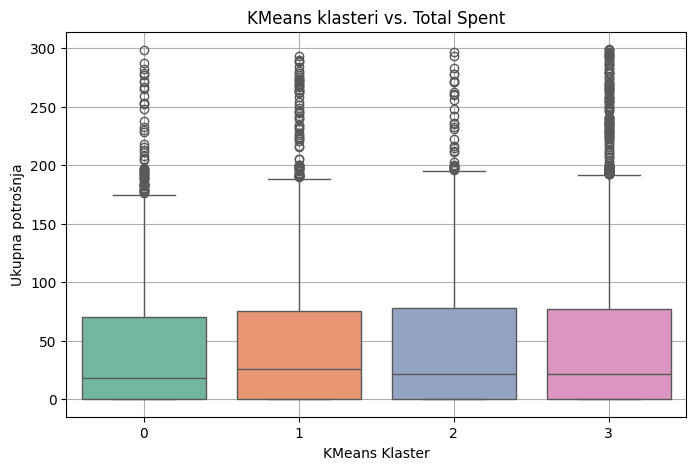

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clustered, x="Cluster", y="total_spent", palette="Set2")
plt.title("KMeans klasteri vs. Total Spent")
plt.xlabel("KMeans Klaster")
plt.ylabel("Ukupna potrošnja")
plt.grid(True)
plt.show()


boxplot gmm klasteri vs total_spent

<ipython-input-18-86c7561df3bd>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_gmm, x="GMM_Cluster", y="total_spent", palette="Set3")


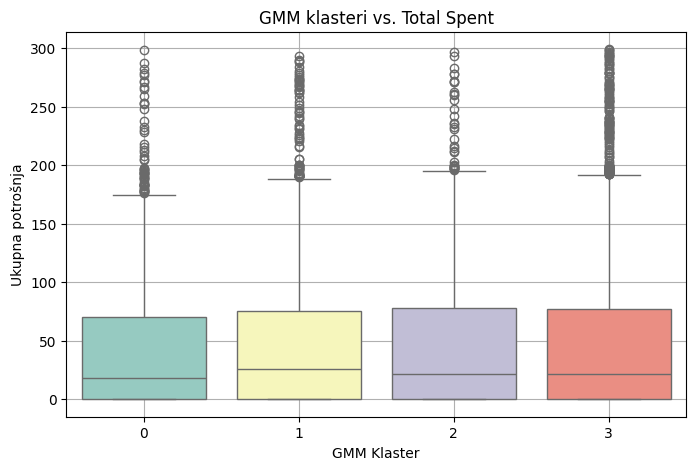

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_gmm, x="GMM_Cluster", y="total_spent", palette="Set3")
plt.title("GMM klasteri vs. Total Spent")
plt.xlabel("GMM Klaster")
plt.ylabel("Ukupna potrošnja")
plt.grid(True)
plt.show()


vizuelizacija pca prostora sa oba algoritma

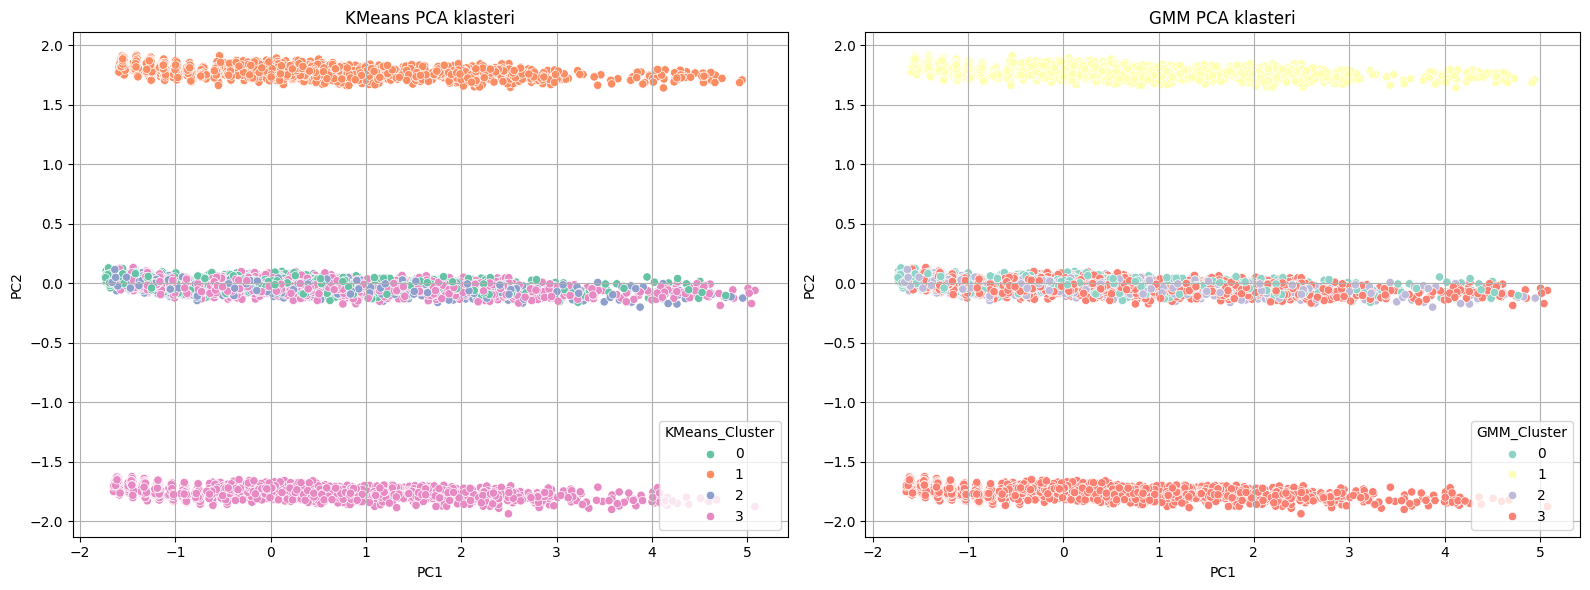

In [19]:
# Dodajemo oznake u PCA podatke
df_pca["KMeans_Cluster"] = kmeans_labels
df_pca["GMM_Cluster"] = gmm_labels

# Uporedni prikaz KMeans vs. GMM
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="KMeans_Cluster", palette="Set2", ax=axes[0])
axes[0].set_title("KMeans PCA klasteri")

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="GMM_Cluster", palette="Set3", ax=axes[1])
axes[1].set_title("GMM PCA klasteri")

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()


Hijerarhijsko klasterovanje - dendogram

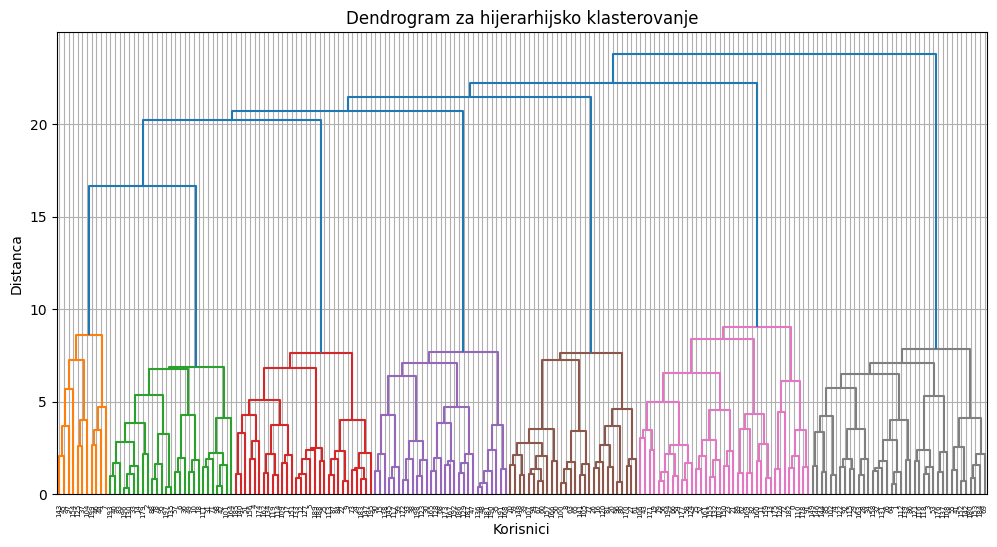

In [20]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Koristimo uzorak podataka radi bolje preglednosti dendrograma
sample_size = 200
sample_data = scaled_data[:sample_size]

linked = linkage(sample_data, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title("Dendrogram za hijerarhijsko klasterovanje")
plt.xlabel("Korisnici")
plt.ylabel("Distanca")
plt.grid(True)
plt.show()


Agglomerative clustering

In [21]:
from sklearn.cluster import AgglomerativeClustering

# Izaberemo broj klastera na osnovu dendrograma (npr. 4)
agglo = AgglomerativeClustering(n_clusters=4)
agglo_labels = agglo.fit_predict(scaled_data)

# Dodajemo rezultat u DataFrame
df_hierarchical = df.copy()
df_hierarchical["Agglo_Cluster"] = agglo_labels
df_pca["Agglo_Cluster"] = agglo_labels


Vizuelizacija klastera (Agglomerative) u PCA prostoru

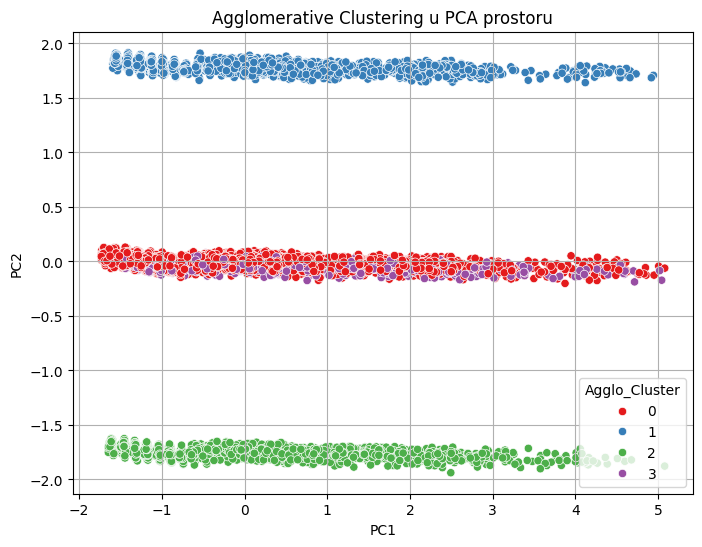

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Agglo_Cluster", palette="Set1")
plt.title("Agglomerative Clustering u PCA prostoru")
plt.grid(True)
plt.show()


Uporedna tabela sa Kmeans i GMM

In [23]:
comparison_df = pd.DataFrame({
    "KMeans": kmeans_labels,
    "GMM": gmm_labels,
    "Agglomerative": agglo_labels
})

# Crosstab za upoređenje
print("KMeans vs Agglomerative:")
print(pd.crosstab(comparison_df["KMeans"], comparison_df["Agglomerative"]))

print("\nGMM vs Agglomerative:")
print(pd.crosstab(comparison_df["GMM"], comparison_df["Agglomerative"]))


KMeans vs Agglomerative:
Agglomerative     0     1     2     3
KMeans                               
0              1483     0     0     0
1                 0  2004     0     0
2              1506     0     0     0
3              1495     0  1997  1515

GMM vs Agglomerative:
Agglomerative     0     1     2     3
GMM                                  
0              1483     0     0     0
1                 0  2004     0     0
2              1506     0     0     0
3              1495     0  1997  1515


Tumačenje rezultata:
Dendrogram pokazuje na kojoj distanci se klasteri spajaju – ako postoji velika “rupa”, to je dobar kandidat za broj klastera.

Crosstab tabele pokazuju koliko se klasteri iz različitih algoritama preklapaju.

Hijerarhijski klasteri su često slični KMeans klasterima kada koristimo ward metodu (baziranu na minimizaciji varijanse).



Sada izracunavamo metrike za sve algoritme

In [24]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def evaluate_clustering(X, labels, name):
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    print(f"\nAlgoritam: {name}")
    print(f"  Silhouette Score:        {sil:.4f}")
    print(f"  Calinski-Harabasz Index: {ch:.2f}")
    print(f"  Davies-Bouldin Index:    {db:.4f}")
    return (name, sil, ch, db)

results = []
results.append(evaluate_clustering(scaled_data, kmeans_labels, "KMeans"))
results.append(evaluate_clustering(scaled_data, gmm_labels, "GMM"))
results.append(evaluate_clustering(scaled_data, agglo_labels, "Agglomerative"))



Algoritam: KMeans
  Silhouette Score:        0.2264
  Calinski-Harabasz Index: 1429.91
  Davies-Bouldin Index:    1.8206

Algoritam: GMM
  Silhouette Score:        0.2264
  Calinski-Harabasz Index: 1429.91
  Davies-Bouldin Index:    1.8206

Algoritam: Agglomerative
  Silhouette Score:        0.2290
  Calinski-Harabasz Index: 1456.35
  Davies-Bouldin Index:    1.8636


Vizuelno poredjenje metrika

<ipython-input-25-2a9d20861f6d>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Algorithm", y="Silhouette", palette="Blues_d")
<ipython-input-25-2a9d20861f6d>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Algorithm", y="Calinski-Harabasz", palette="Greens_d")
<ipython-input-25-2a9d20861f6d>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Algorithm", y="Davies-Bouldin", palette="Reds_d")


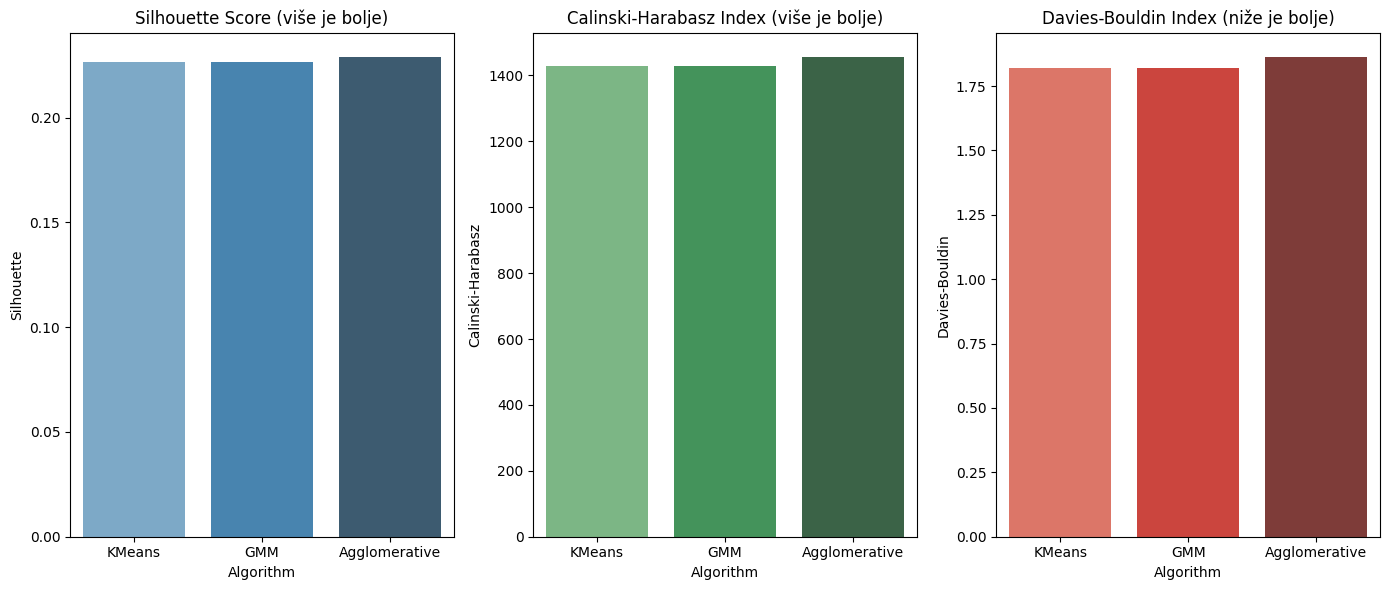

In [25]:
# Pretvaramo u DataFrame za prikaz
results_df = pd.DataFrame(results, columns=["Algorithm", "Silhouette", "Calinski-Harabasz", "Davies-Bouldin"])

# Barplot za sve metrike
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
sns.barplot(data=results_df, x="Algorithm", y="Silhouette", palette="Blues_d")
plt.title("Silhouette Score (više je bolje)")

plt.subplot(1, 3, 2)
sns.barplot(data=results_df, x="Algorithm", y="Calinski-Harabasz", palette="Greens_d")
plt.title("Calinski-Harabasz Index (više je bolje)")

plt.subplot(1, 3, 3)
sns.barplot(data=results_df, x="Algorithm", y="Davies-Bouldin", palette="Reds_d")
plt.title("Davies-Bouldin Index (niže je bolje)")

plt.tight_layout()
plt.show()


Najviši Silhouette Score → pokazuje koji algoritam je najbolje razdvojio i formirao klastere.

Najviši CH Index → označava veliku razliku između klastera i malu disperziju unutar klastera.

Najniži DB Index → znači da su klasteri najkompaktniji i najbolje razdvojeni.

README:

# Customer Segmentation using Unsupervised Learning

This project applies multiple **unsupervised machine learning algorithms** to perform **customer segmentation** for a simulated online store dataset. The goal is to identify distinct user profiles based on behavioral and transactional data.

---

## Project Overview

We generate a synthetic dataset of 1000 users with the following features:
- `site_visits`: number of website visits  
- `products_viewed_per_visit`: average number of products viewed  
- `avg_time_on_site`: average session duration (minutes)  
- `items_in_cart`: items added to cart  
- `purchases`: number of purchases made  
- `total_spent`: total money spent  
- `country`: user location

---

## Workflow Summary

### 1. **Data Generation**
- Synthetic data created using `make_blobs`, `numpy`, and logical distributions.

### 2. **Data Exploration & Preprocessing**
- Descriptive statistics, heatmaps, and pairplots  
- One-hot encoding for categorical features  
- Feature scaling using `StandardScaler`  
- Dimensionality reduction with `PCA` (2D)

### 3. **Clustering Algorithms Applied**
- **KMeans** (elbow method + silhouette score)
- **DBSCAN** (density-based)
- **Gaussian Mixture Models (GMM)** (probabilistic clustering)
- **Hierarchical Clustering** (dendrogram + agglomerative labels)

### 4. **Evaluation Metrics**
- `Silhouette Score` – cluster cohesion and separation  
- `Calinski-Harabasz Index` – between/within variance ratio  
- `Davies-Bouldin Index` – compactness and separation

### 5. **Results Comparison**
- Visual and quantitative comparison across all algorithms  
- User segmentation profiles derived from cluster analysis  
- Recommendation of the most effective clustering strategy

---

## Visualizations

- PCA scatter plots with cluster coloring  
- Boxplots of `total_spent` per cluster  
- Dendrogram for hierarchical structure  
- Bar charts comparing evaluation metrics

---

## Requirements

Install required packages:
```bash
pip install pandas numpy scikit-learn seaborn matplotlib scipy
